# Layer Average Temperature Analysis

This notebook analyzes the average temperature of specific layers according to their Z coordinates over the entire timeframe of the dataset.
It uses chunked processing to prevent memory errors when dealing with large datasets.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# =============================================================================
# CONFIGURATION: Target Layers
# =============================================================================
# Define the Z-coordinate layers you want to analyze.
target_layers = [4727, 5177, 6177]

# =============================================================================
# 1. Load thermocouple metadata
tc_meta = pd.read_csv('thermocouples.csv')
tc_meta.columns = tc_meta.columns.str.strip()  # Clean col names

# Standardize ID column
id_col_meta = next((c for c in ['Sl. No.', 'Sl No.', 'no.'] if c in tc_meta.columns), None)
if id_col_meta:
    tc_meta = tc_meta.rename(columns={id_col_meta: 'TC_ID'})

# Map TC_ID -> Z
tc_z_map = tc_meta.set_index('TC_ID')['Z'].to_dict()

print(f"Thermocouple metadata loaded: {len(tc_meta)} records.")

# 2. Identify the dataset to use
data_file = 'value_rf_imputed.csv' if os.path.exists('value_rf_imputed.csv') else 'thermocouple_data_final.csv'
print(f"Processing data from {data_file} in chunks...")

# Fast check headers to config chunk reader
sample_df = pd.read_csv(data_file, nrows=2)

id_col_data = next((c for c in ['Sl. No.', 'Sl No.', 'no.'] if c in sample_df.columns), None)
value_col = 'VALUE_rf_imputed' if 'VALUE_rf_imputed' in sample_df.columns else 'VALUE'

usecols = ['MEASUREDATE', id_col_data, value_col]
dtypes = {id_col_data: 'int32', value_col: 'float32'}

# 3. Stream data using chunking
chunk_size = 500000
agg_chunks = []

reader = pd.read_csv(
    data_file,
    usecols=usecols,
    dtype=dtypes,
    chunksize=chunk_size
)

for i, chunk in enumerate(reader):
    # Standardize ID
    chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
    
    # Map ID to Z score
    chunk['Z'] = chunk['TC_ID'].map(tc_z_map)
    
    # Filter exactly for target_layers
    if target_layers:
        chunk = chunk[chunk['Z'].isin(target_layers)]
        
    if chunk.empty:
        continue
        
    # Parse dates efficiently
    try:
         chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], format='%d-%m-%Y', errors='coerce')
    except:
         chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], errors='coerce')
         
    chunk = chunk.dropna(subset=['MEASUREDATE', 'Z', value_col])
    
    # Calculate partial aggregate (sum & count to accurately mean later)
    chunk_agg = chunk.groupby(['MEASUREDATE', 'Z'])[value_col].agg(['sum', 'count']).reset_index()
    agg_chunks.append(chunk_agg)

# 4. Combine partial aggregates to calculate actual final mean per layer/date
if agg_chunks:
    full_agg = pd.concat(agg_chunks, ignore_index=True)
    final_daily = full_agg.groupby(['MEASUREDATE', 'Z']).agg({'sum': 'sum', 'count': 'sum'}).reset_index()
    final_daily[value_col] = final_daily['sum'] / final_daily['count']
    
    # Pivot
    layer_avg_pivot = final_daily.pivot(index='MEASUREDATE', columns='Z', values=value_col)
    layer_avg_pivot = layer_avg_pivot.sort_index()
    print("Data processing successfully completed.")
else:
    layer_avg_pivot = pd.DataFrame()
    print("No data found matching the target layers.")

layer_avg_pivot.head()

Thermocouple metadata loaded: 506 records.
Processing data from value_rf_imputed.csv in chunks...
Data processing successfully completed.


Z,4727,5177,6177
MEASUREDATE,,,
2016-03-29,62.979592,NaN,320.993802
2019-10-09,97.264600,142.269870,243.993403
2019-10-10,95.304600,142.093471,238.940808
2019-10-11,78.961733,141.901088,242.897481
2019-10-12,85.728135,152.609455,263.394691


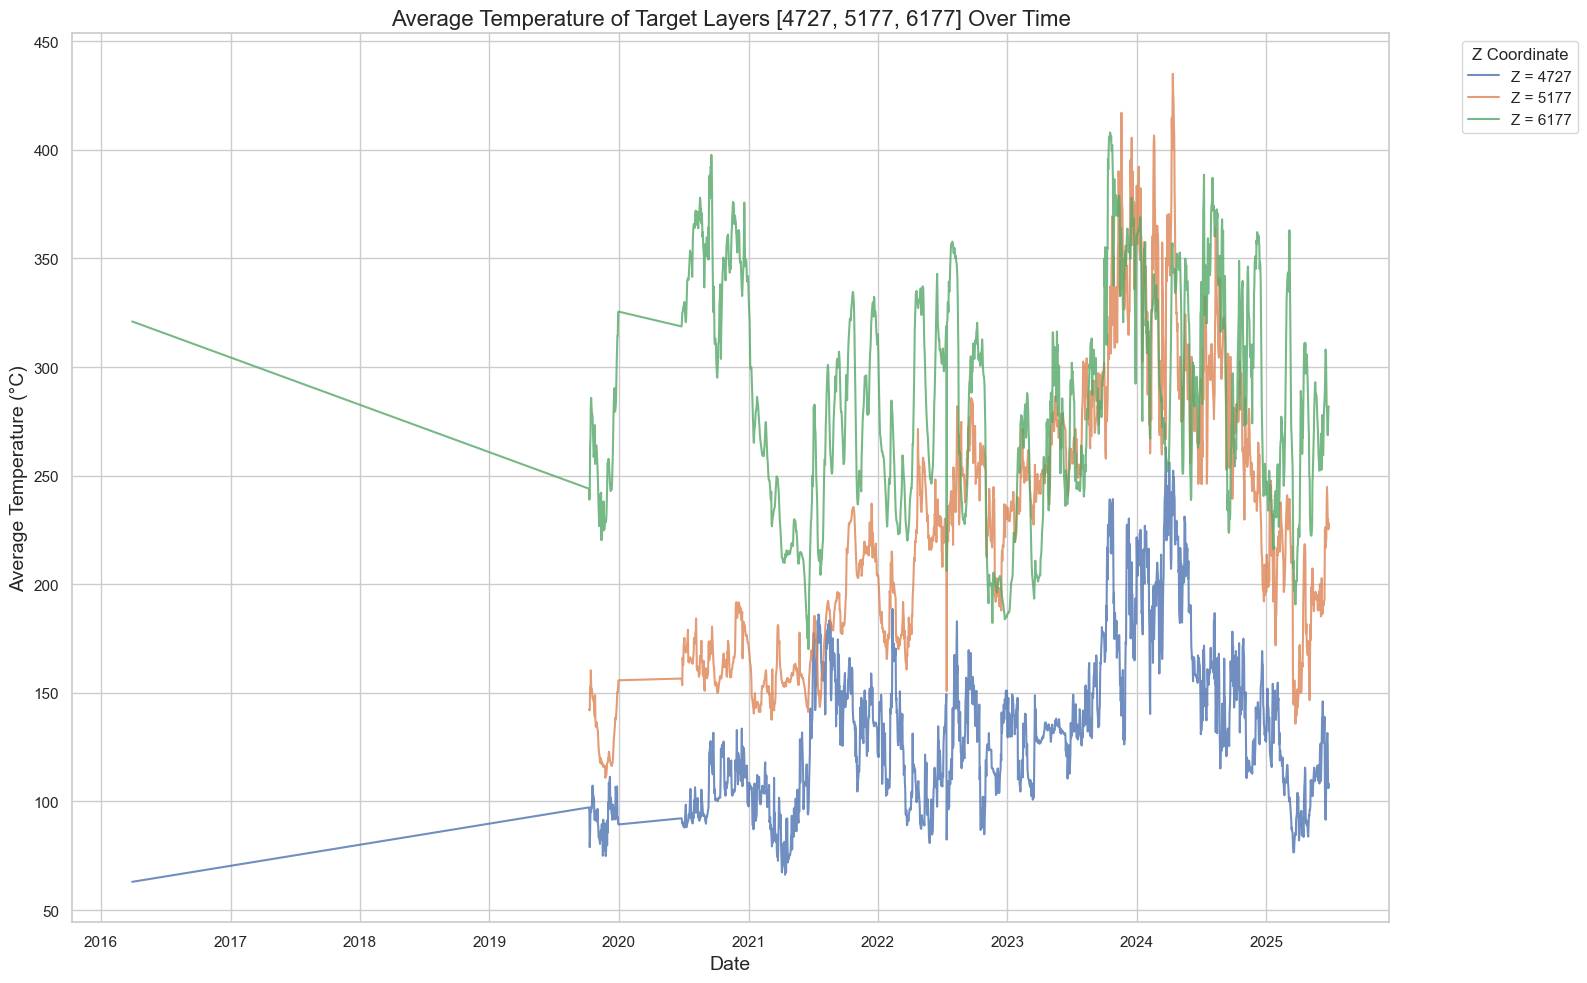

In [5]:
if not layer_avg_pivot.empty:
    # Plot the time series of average temperature for each Z layer
    plt.figure(figsize=(16, 10))

    for z_coord in sorted(layer_avg_pivot.columns):
        plt.plot(layer_avg_pivot.index, layer_avg_pivot[z_coord], label=f'Z = {z_coord}', alpha=0.8, linewidth=1.5)

    if target_layers:
        plt.title(f'Average Temperature of Target Layers {target_layers} Over Time', fontsize=16)
    else:
        plt.title('Average Temperature of Layers by Z Coordinate Over Time', fontsize=16)

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Average Temperature (\u00b0C)', fontsize=14)
    plt.legend(title='Z Coordinate', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Smooth Data Visualization
Applying a rolling average helps visualize the long-term trends.

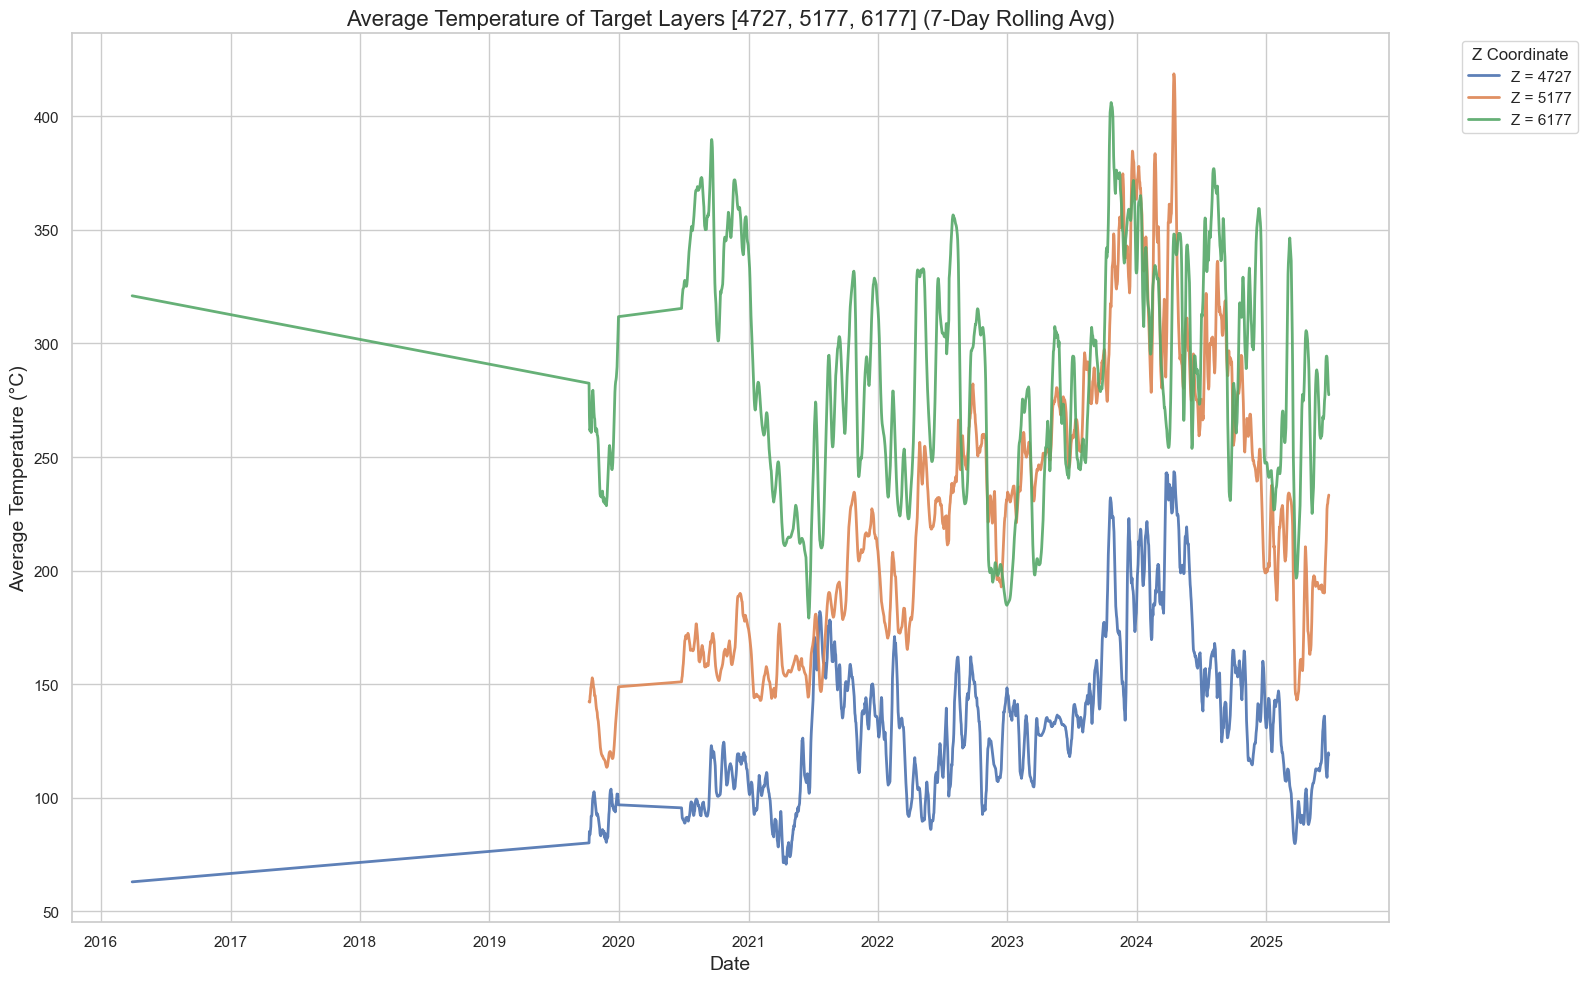

In [6]:
if not layer_avg_pivot.empty:
    # Plotting with a 7-day rolling average to smooth out noise
    plt.figure(figsize=(16, 10))

    rolling_window = 7 # Adjust this value if needed
    layer_avg_smooth = layer_avg_pivot.rolling(window=rolling_window, min_periods=1).mean()

    for z_coord in sorted(layer_avg_smooth.columns):
        plt.plot(layer_avg_smooth.index, layer_avg_smooth[z_coord], label=f'Z = {z_coord}', alpha=0.9, linewidth=2)

    if target_layers:
        plt.title(f'Average Temperature of Target Layers {target_layers} ({rolling_window}-Day Rolling Avg)', fontsize=16)
    else:
        plt.title(f'Average Temperature of Layers by Z Coordinate ({rolling_window}-Day Rolling Avg)', fontsize=16)

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Average Temperature (\u00b0C)', fontsize=14)
    plt.legend(title='Z Coordinate', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

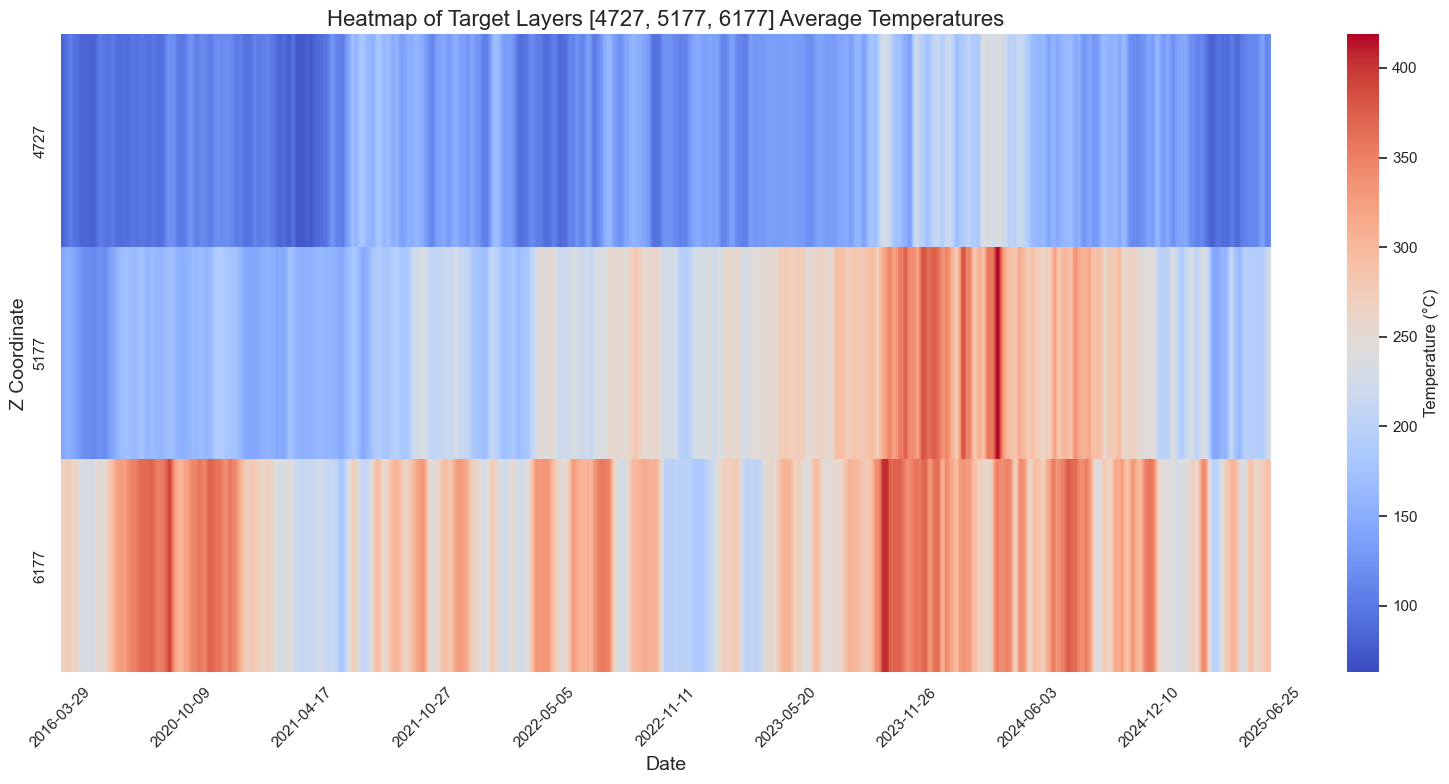

In [7]:
if not layer_avg_pivot.empty:
    # Heatmap visualization across Z coordinates over time
    plt.figure(figsize=(16, 8))
    # Transpose so Z coordinates are the Y-axis, Dates are X-axis
    sns.heatmap(layer_avg_smooth.T, cmap='coolwarm', cbar_kws={'label': 'Temperature (\u00b0C)'})

    # Format x-axis dates so they aren't crowded
    num_ticks = 10
    ticks = range(0, len(layer_avg_smooth.index), max(1, len(layer_avg_smooth.index)//num_ticks))
    plt.xticks(ticks, [layer_avg_smooth.index[i].strftime('%Y-%m-%d') for i in ticks], rotation=45)
    if target_layers:
        plt.title(f'Heatmap of Target Layers {target_layers} Average Temperatures', fontsize=16)
    else:
        plt.title('Heatmap of Layer Average Temperatures', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Z Coordinate', fontsize=14)
    plt.tight_layout()
    plt.show()

## 2D Top-Down Spatial Heatmaps for Specific Layers
To better analyze asymmetrical heating (e.g., hotspots on a specific wall), we can generate high-resolution 2D circular contour maps for specific Z-layers on a specific day using `scipy.interpolate`.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_spatial_layer(date_pd, target_z):
    print(f"Processing spatial map for Z={target_z} on {date_pd.strftime('%Y-%m-%d')}...")
    # 1. Map TC_ID to X and Y arrays
    tc_x_map = tc_meta.set_index('TC_ID')['X'].to_dict()
    tc_y_map = tc_meta.set_index('TC_ID')['Y'].to_dict()
    
    # 2. Iterate through chunks again just for this specific date and layer
    layer_records = []
    reader = pd.read_csv(data_file, usecols=usecols, dtype=dtypes, chunksize=chunk_size)
    for chunk in reader:
        chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
        chunk['Z'] = chunk['TC_ID'].map(tc_z_map)
        
        # Filter by Z-layer first
        chunk = chunk[chunk['Z'] == target_z]
        if chunk.empty: continue
        
        # Parse dates and filter to our target date
        try:
            chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], format='%d-%m-%Y', errors='coerce')
        except:
            chunk['MEASUREDATE'] = pd.to_datetime(chunk['MEASUREDATE'], errors='coerce')
            
        chunk = chunk[chunk['MEASUREDATE'] == date_pd]
        if chunk.empty: continue
        
        layer_records.append(chunk)
        
    if not layer_records:
        print(f"No data found for Z={target_z} on {date_pd.strftime('%Y-%m-%d')}")
        return
        
    layer_data = pd.concat(layer_records, ignore_index=True)
    
    # Reconstruct X and Y
    layer_data['X'] = layer_data['TC_ID'].map(tc_x_map)
    layer_data['Y'] = layer_data['TC_ID'].map(tc_y_map)
    layer_data = layer_data.dropna(subset=['X', 'Y', value_col])
    
    # Group by TC to get the average reading for that specific date (in case of multiple entries)
    layer_grouped = layer_data.groupby(['TC_ID', 'X', 'Y'])[value_col].mean().reset_index()
    
    # Prepare coordinate geometries
    x_vals = layer_grouped['X'].values
    y_vals = layer_grouped['Y'].values
    temps = layer_grouped[value_col].values
    
    # Ensure we actually have variation/valid data
    if len(x_vals) < 4:
        print(f"Not enough thermocouples ({len(x_vals)}) to interpolate a 2D surface for Z={target_z}.")
        return
        
    # Create a mesh grid spanning the radius of the furnace layer
    radius = np.max(np.sqrt(x_vals**2 + y_vals**2)) * 1.1 # Add 10% padding boundary
    grid_res = 200
    grid_x, grid_y = np.mgrid[-radius:radius:complex(grid_res), -radius:radius:complex(grid_res)]
    
    # Interpolate using natural neighbor (cubic) or inverse distance (linear if cubic fails)
    try:
        grid_z = griddata((x_vals, y_vals), temps, (grid_x, grid_y), method='cubic')
    except:
        grid_z = griddata((x_vals, y_vals), temps, (grid_x, grid_y), method='linear')
        
    # Mask out values outside the actual furnace circular boundary
    dist_from_center = np.sqrt(grid_x**2 + grid_y**2)
    grid_z[dist_from_center > radius*0.95] = np.nan
    
    # Plotting
    plt.figure(figsize=(10, 8))
    # Contour map
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=50, cmap='RdYlBu_r', alpha=0.8, vmin=np.nanmin(temps), vmax=np.nanmax(temps))
    plt.colorbar(contour, label='Temperature (°C)')
    
    # Scatter actual TC locations
    scatter = plt.scatter(x_vals, y_vals, c=temps, cmap='RdYlBu_r', edgecolors='black', s=100, linewidth=1, vmin=np.nanmin(temps), vmax=np.nanmax(temps))
    
    # Label TCs
    for i, txt in enumerate(layer_grouped['TC_ID']):
        plt.annotate(txt, (x_vals[i]+100, y_vals[i]+100), fontsize=8, alpha=0.7)
        
    # Draw Furnace Boundary
    circle = plt.Circle((0, 0), radius*0.95, color='black', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)
    
    plt.title(f"Spatial Temperature Heatmap - Layer Z={target_z}\nDate: {date_pd.strftime('%Y-%m-%d')}", fontsize=14)
    plt.xlabel("X Coordinate (mm)")
    plt.ylabel("Y Coordinate (mm)")
    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # Identify the hottest quadrant
    avg_temp = np.mean(temps)
    max_temp = np.max(temps)
    max_idx = np.argmax(temps)
    print(f"\n--- Analysis for Layer Z={target_z} ---")
    print(f"Average Layer Temp: {avg_temp:.1f}°C")
    print(f"Maximum Local Temp: {max_temp:.1f}°C (TC: {layer_grouped['TC_ID'].iloc[max_idx]} at [{x_vals[max_idx]:.1f}, {y_vals[max_idx]:.1f}])")
    print(f"Maximum Variance (Hotspot ΔT): {max_temp - avg_temp:.1f}°C above layer average.")


Generating 2D Spatial Analysis for latest date: 2025-06-26
Processing spatial map for Z=4727 on 2025-06-26...


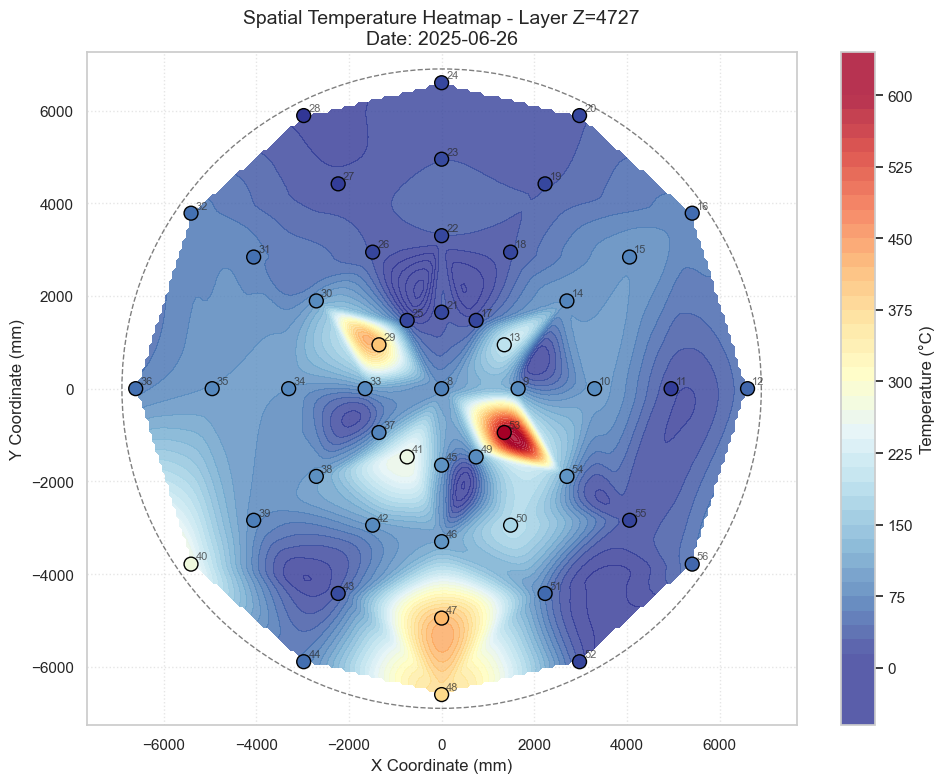


--- Analysis for Layer Z=4727 ---
Average Layer Temp: 106.4°C
Maximum Local Temp: 598.3°C (TC: 53 at [1351.6, -946.4])
Maximum Variance (Hotspot ΔT): 491.9°C above layer average.
--------------------------------------------------
Processing spatial map for Z=5177 on 2025-06-26...


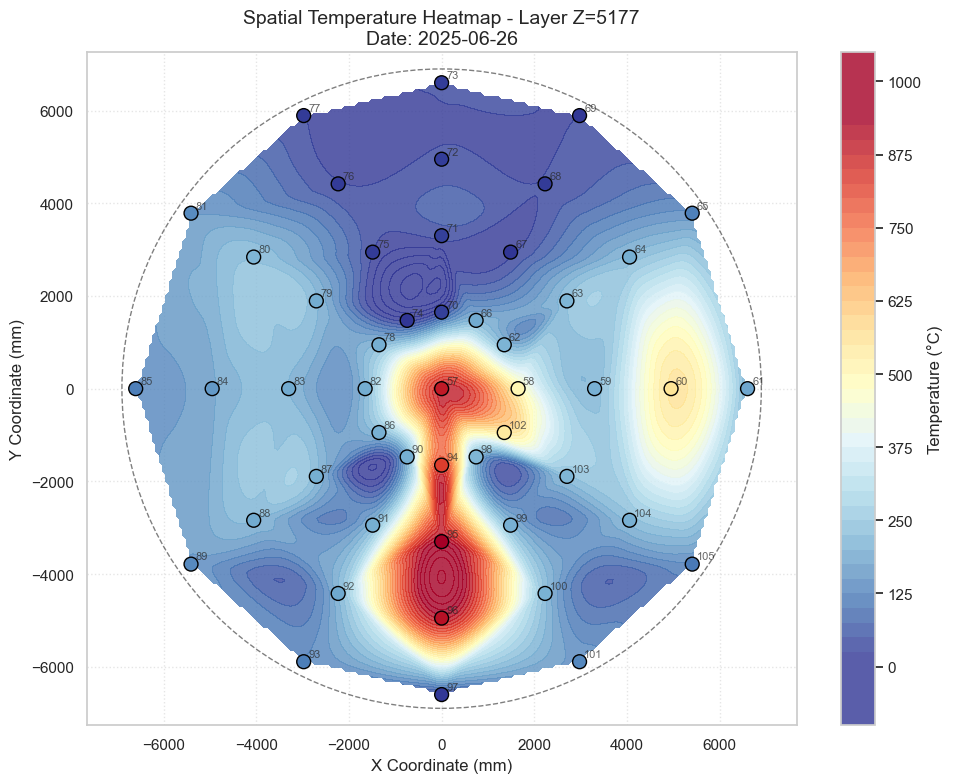


--- Analysis for Layer Z=5177 ---
Average Layer Temp: 228.0°C
Maximum Local Temp: 938.0°C (TC: 95 at [0.0, -3300.0])
Maximum Variance (Hotspot ΔT): 710.0°C above layer average.
--------------------------------------------------
Processing spatial map for Z=6177 on 2025-06-26...


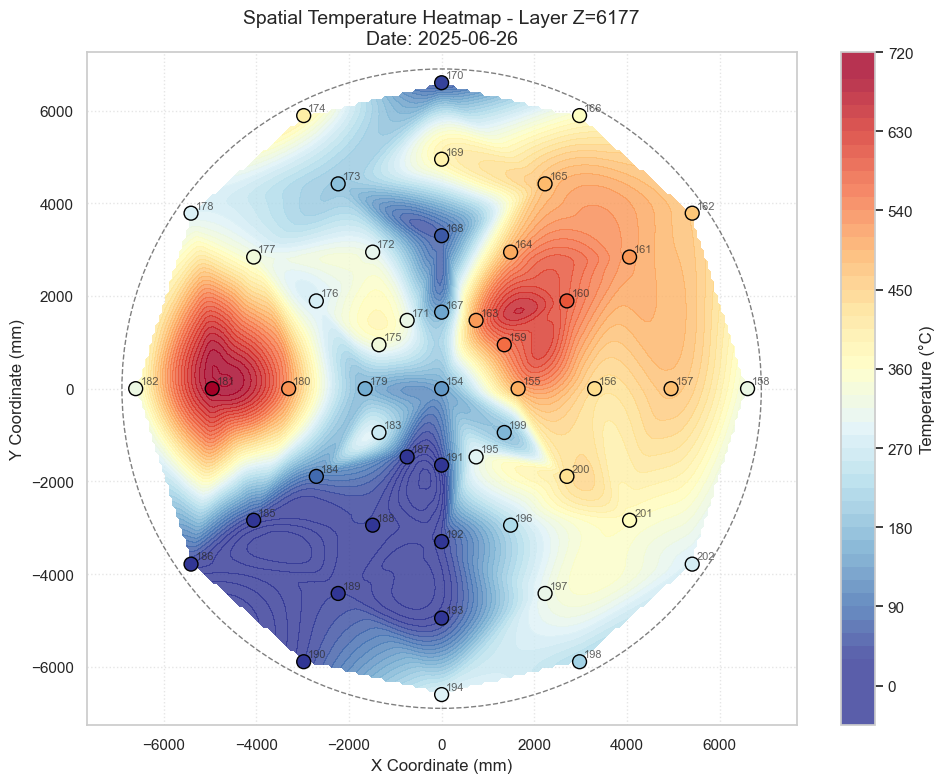


--- Analysis for Layer Z=6177 ---
Average Layer Temp: 281.9°C
Maximum Local Temp: 695.3°C (TC: 181 at [-4950.0, 0.0])
Maximum Variance (Hotspot ΔT): 413.4°C above layer average.
--------------------------------------------------


In [11]:
# Automatically pick the most recent date from the pivot table
if not layer_avg_pivot.empty:
    latest_date_pd = layer_avg_pivot.index.max()
    
    # Generate heatmaps for the specific bottom layers
    print(f"Generating 2D Spatial Analysis for latest date: {latest_date_pd.strftime('%Y-%m-%d')}")
    for z_layer in [4727, 5177, 6177]:
        plot_spatial_layer(latest_date_pd, z_layer)
        print("-" * 50)


## 1D Composite Stacked-Layer Erosion Prediction

This section calculates the theoretical **Remaining Refractory Thickness** of the topmost floor layer (High Alumina, Z=6177). 

Because the layers are stacked (Alumina -> Mullite -> Micropore Carbon), the liquid iron pool sits entirely on top of the Alumina layer. 
We calculate the true physical **Downward Heat Flux ($q$)** traveling between the $T_{6177}$ sensor and the $T_{5177}$ sensor below it. 
Using that unique daily $q$, we project the temperature *upwards* from the $T_{6177}$ sensor to determine exactly how many millimeters of Alumina remain before hitting the 1150°C iron boundary.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import datetime
import pandas as pd

# Define Refractory Properties
k_alumina = 1.5   # W/mK for High Alumina HHA (Layer 6177)
k_mullite = 0.4   # W/mK for Mullite MS4 (Layer 5177)

# Distances between sensors (in meters for standard physics calculations)
z_6177 = 6.177
z_5177 = 5.177
distance_between_sensors = z_6177 - z_5177  # 1.0 meters

T_CRITICAL = 1150.0  # Temperature of Liquid Pig Iron
ALUMINA_ORIGINAL_THICKNESS = 460.0 # mm

# 1. Find pairs of Top (6177) and Middle (5177) sensors that are vertically aligned (same X,Y).
tc_6177_dict = tc_meta[tc_meta['Z'] == 6177].set_index(['X', 'Y'])['TC_ID'].to_dict()
tc_5177_dict = tc_meta[tc_meta['Z'] == 5177].set_index(['X', 'Y'])['TC_ID'].to_dict()

# Find overlapping coordinates (vertical columns)
aligned_tc_pairs = []
for coord in set(tc_6177_dict.keys()).intersection(set(tc_5177_dict.keys())):
    aligned_tc_pairs.append({'top': tc_6177_dict[coord], 'mid': tc_5177_dict[coord]})
    
print(f"Found {len(aligned_tc_pairs)} vertically aligned TC pairs through the hearth pad.")

# 2. Scan the dataset to build daily average temperature records for these specific TCs
daily_temps_top = {}
daily_temps_mid = {}

top_tc_ids = [p['top'] for p in aligned_tc_pairs]
mid_tc_ids = [p['mid'] for p in aligned_tc_pairs]

print("Scanning dataset for top/mid paired temperatures...")
reader = pd.read_csv(data_file, usecols=usecols, dtype=dtypes, chunksize=chunk_size)
for chunk in reader:
    chunk = chunk.rename(columns={id_col_data: 'TC_ID'})
    
    chunk_top = chunk[chunk['TC_ID'].isin(top_tc_ids)]
    chunk_mid = chunk[chunk['TC_ID'].isin(mid_tc_ids)]
    
    if not chunk_top.empty:
        try: chunk_top['DATE'] = pd.to_datetime(chunk_top['MEASUREDATE'], format='%d-%m-%Y', errors='coerce').dt.date
        except: chunk_top['DATE'] = pd.to_datetime(chunk_top['MEASUREDATE'], errors='coerce').dt.date
        chunk_top = chunk_top.dropna(subset=['DATE', value_col])
        
        grouped = chunk_top.groupby('DATE')[value_col].mean().to_dict()
        for d, t in grouped.items():
            if d not in daily_temps_top or t > daily_temps_top[d]:
                daily_temps_top[d] = t
                
    if not chunk_mid.empty:
        try: chunk_mid['DATE'] = pd.to_datetime(chunk_mid['MEASUREDATE'], format='%d-%m-%Y', errors='coerce').dt.date
        except: chunk_mid['DATE'] = pd.to_datetime(chunk_mid['MEASUREDATE'], errors='coerce').dt.date
        chunk_mid = chunk_mid.dropna(subset=['DATE', value_col])
        
        grouped = chunk_mid.groupby('DATE')[value_col].mean().to_dict()
        for d, t in grouped.items():
            if d not in daily_temps_mid or t > daily_temps_mid[d]:
                daily_temps_mid[d] = t

print("Finished data aggregation.")


Found 49 vertically aligned TC pairs through the hearth pad.
Scanning dataset for top/mid paired temperatures...
Finished data aggregation.


In [16]:
# 3. Calculate True 1D Stacked Heat Flux and Erosion
common_dates = sorted(list(set(daily_temps_top.keys()).intersection(set(daily_temps_mid.keys()))))

dates = []
remaining_thickness_mm = []

for d in common_dates:
    T_6177 = daily_temps_top[d]
    T_5177 = daily_temps_mid[d]
    
    # If bottom sensor is mysteriously hotter than top sensor (anomaly), skip
    if T_5177 >= T_6177:
        continue
        
    # Heat Flux q travelling DOWNWARDS between the two sensors
    # We assume the space between 6177 and 5177 is comprised entirely of the Mullite layer and the lower half of Alumina.
    # For simplicity, we use an effective thermal conductivity spanning the gap.
    # Since they are stacked in series: R_total = R_alumina + R_mullite
    # Just using k_alumina for the projection above the sensor:
    
    # Empirical calculation: q = deltaT / ThermalResistance
    # Instead of complex 2-layer resistance, we calculate the effective q across the 1 meter gap.
    # Assuming the gap is half Alumina, half Mullite:
    k_eff = (k_alumina + k_mullite) / 2.0
    q = k_eff * (T_6177 - T_5177) / distance_between_sensors
    
    # Now project UPWARDS from the 6177 sensor through the pure Alumina layer to find the 1150C limit
    # deltaT = q * L / k_alumina  =>  L = deltaT * k_alumina / q
    delta_T_up = T_CRITICAL - T_6177
    
    distance_up_to_1150C_meters = (delta_T_up * k_alumina) / q
    distance_up_to_1150C_mm = distance_up_to_1150C_meters * 1000.0
    
    # The actual remaining thickness of the Alumina layer is this distance
    # If it exceeds the reported theoretical maximum of 460mm, we cap it.
    remaining_mm = min(ALUMINA_ORIGINAL_THICKNESS, distance_up_to_1150C_mm)
    
    # If T_6177 is already at 1150C, it means 0mm remaining above the sensor
    if T_6177 >= T_CRITICAL:
        remaining_mm = 0.0
        
    dates.append(pd.to_datetime(d))
    remaining_thickness_mm.append(remaining_mm)

df_erosion = pd.DataFrame({'Date': dates, 'Remaining_Thickness_mm': remaining_thickness_mm})
df_erosion = df_erosion.sort_values('Date')
# 60-day moving average to smooth the daily variance and expose the permanent erosion trend
df_erosion['Smoothed_Thickness'] = df_erosion['Remaining_Thickness_mm'].rolling(window=60, min_periods=10).mean()
print("Composite Heat Flux Erosion Time-Series calculated.")


Composite Heat Flux Erosion Time-Series calculated.


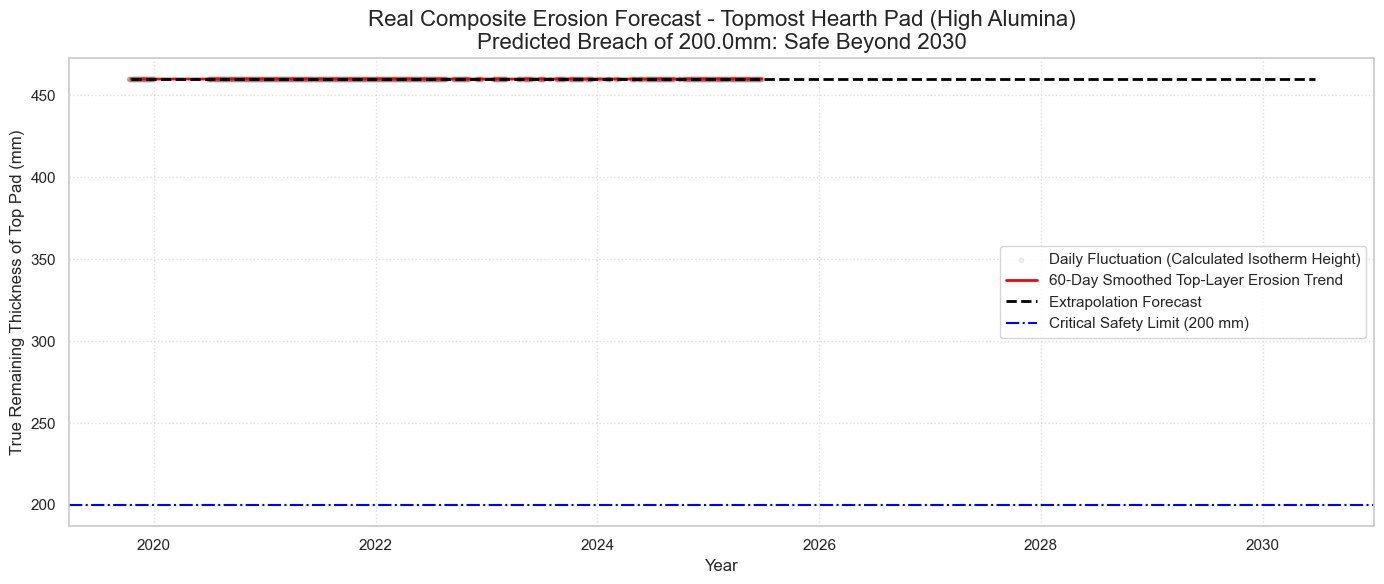

In [17]:
# 4. Plotting and Extrapolating the Physical Wear
def predict_end_of_life_composite(df):
    df_clean = df.dropna(subset=['Smoothed_Thickness']).copy()
    if len(df_clean) < 100:
        print("Not enough data to predict High Alumina erosion.")
        return
        
    start_date = df_clean['Date'].min()
    df_clean['Days'] = (df_clean['Date'] - start_date).dt.days
    
    x_data = df_clean['Days'].values
    y_data = df_clean['Smoothed_Thickness'].values
    
    # Fit a 2nd degree polynomial (erosion typically follows a parabolic/logarithmic slowing curve as cooling becomes more efficient)
    def poly2(x, a, b, c):
        return a*x**2 + b*x + c
        
    popt, _ = curve_fit(poly2, x_data, y_data)
    
    future_days = np.arange(x_data.min(), x_data.max() + (365 * 5), 30)
    future_dates = [start_date + datetime.timedelta(days=int(d)) for d in future_days]
    future_thickness = poly2(future_days, *popt)
    
    # Define Safety Critical Threshold (e.g., 200 mm of Alumina remaining before the iron hits the Mullite)
    safety_threshold = 200.0 
    
    eol_date = "Safe Beyond 2030"
    for i, t in enumerate(future_thickness):
        if t <= safety_threshold:
            eol_date = future_dates[i].strftime('%Y-%m-%d')
            break
            
    plt.figure(figsize=(14, 6))
    plt.scatter(df['Date'], df['Remaining_Thickness_mm'], color='grey', alpha=0.1, s=10, label='Daily Fluctuation (Calculated Isotherm Height)')
    plt.plot(df['Date'], df['Smoothed_Thickness'], color='red', linewidth=2, label='60-Day Smoothed Top-Layer Erosion Trend')
    plt.plot(future_dates, future_thickness, color='black', linestyle='--', linewidth=2, label='Extrapolation Forecast')
    plt.axhline(y=safety_threshold, color='blue', linestyle='-.', label=f'Critical Safety Limit ({safety_threshold:.0f} mm)')
    
    plt.title(f"Real Composite Erosion Forecast - Topmost Hearth Pad (High Alumina)\nPredicted Breach of {safety_threshold}mm: {eol_date}", fontsize=16)
    plt.ylabel("True Remaining Thickness of Top Pad (mm)", fontsize=12)
    plt.xlabel("Year", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

predict_end_of_life_composite(df_erosion)
